In [1]:
import ytree

import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches 

import pandas as pd

from astropy.cosmology import Planck15
from astropy.cosmology import FlatLambdaCDM

cosmo_15 = FlatLambdaCDM(Planck15.H0, Planck15.Om0, m_nu=Planck15.m_nu, Ob0=Planck15.Ob0)

import pickle 

In [2]:
cosmo_15.age([0, 1, 2]).value

array([13.82033644,  5.87886497,  3.29492062])

In [3]:
def r(a, b):
    return float((a['x'] - b['x'])**2 + (a['y'] - b['y'])**2  + (a['z'] - b['z'])**2)**(0.5)

def theta(a, b):
    if (a['z'] - b['z']) > 0: 
        return np.arctan( ( (a['x'] - b['x'])**2 + (a['y'] - b['y'])**2 )**(0.5)/ (a['z'] - b['z']) ) 
    elif (a['z'] - b['z']) < 0: 
        return np.pi + np.arctan( ( (a['x'] - b['x'])**2 + (a['y'] - b['y'])**2 )**(0.5)/ (a['z'] - b['z']) ) 
    elif (a['z'] - b['z']) == 0 and (a['y'] - b['y'])*(a['x'] - b['x']) != 0:
        return np.pi / 2
    
    return np.nan 

def phi(a, b):
    if (a['x'] - b['x']) > 0: 
        return np.arctan( (a['y'] - b['y']) / (a['x'] - b['x']) ) 
    elif (a['x'] - b['x']) < 0 and (a['y'] - b['y']) >= 0: 
        return np.arctan((a['y'] - b['y']) / (a['x'] - b['x']) ) + np.pi
    elif (a['x'] - b['x']) < 0 and (a['y'] - b['y']) < 0: 
        return np.arctan((a['y'] - b['y']) / (a['x'] - b['x']) ) - np.pi 
    elif (a['x'] - b['x']) == 0 and (a['y'] - b['y']) > 0: 
        return np.pi / 2 
    elif (a['x'] - b['x']) == 0 and (a['y'] - b['y']) < 0: 
        return -np.pi / 2
    
    return np.nan 

In [4]:
# given a set of nodes, calculate the distance fraction from the final descendent based on Rvir,desc 
# return angle too ?

def calc_Rratio(nodes, parent): 
    r_d = np.array([r(node, parent) / float(parent['Rvir'] * 1 / 1e3) for node in nodes])
    
    th = np.array([theta(node, parent) for node in nodes])
    
    ph = np.array([phi(node, parent) for node in nodes])
    
    return r_d, th , ph

In [5]:
# grab a tree and its nodes 
def get_branches(mvir_min, tree_idx=24):
    tree_nodes = list(a[tree_idx]['tree'])

    # get the number of total halos in the tree without any pruning 
    nhalos = len(tree_nodes)

    # initialize a holder for the indices of the branch
    branch_idx = []
    # merging = {node: {} for node in tree_nodes[0]["prog", "id"]}

    # value for indexing the tree_nodes .. 
    idx = 0 

    # hard coding in the main branch right now ... 
    # main branch is always first index ... 
    branch_idx.append([0, 0 + len(tree_nodes[idx]["prog", "id"])])
    main_ids = np.array([node['id'] for node in tree_nodes[branch_idx[0][0]:branch_idx[0][1]]])
    nhalos = nhalos - (branch_idx[0][1] - branch_idx[0][0])
    idx = idx + (branch_idx[-1][1] - branch_idx[-1][0])

    while nhalos > 0:
        if tree_nodes[idx]['Mvir']  > mvir_min and tree_nodes[idx]['desc_id'] in main_ids: 
            branch_idx.append([idx, idx + len(tree_nodes[idx]["prog", "id"])])

        nhalos = nhalos - len(tree_nodes[idx]["prog", "id"])
        idx = idx + len(tree_nodes[idx]["prog", "id"])


    branch_idx = np.array(branch_idx)

    branch_dfs = []

    names = np.array(['scale', 'logmvir', 'logrvir', 'Vmax_DM', 
                      'halo_conc', 'Rratio', 'theta', 'phi'])

    scale = None
    
    for i in range(0, len(branch_idx)): 
        q_arr = []
        nodes = [node for node in tree_nodes[branch_idx[i][0]:branch_idx[i][1]]]
        
        q_arr.append((np.array([node['scale'] for node in nodes])))
        q_arr.append(np.log10(np.array([node['Mvir'].value / cosmo_15.h for node in nodes])))
        q_arr.append(np.log10(np.array([node['Rvir'].value / cosmo_15.h for node in nodes])))
        q_arr.append((np.array([node['vmax'].value for node in nodes])))
        q_arr.append((np.array([node['Rvir']/node['rs'] for node in nodes])))


        if i > 0: 
            d, th, phi = calc_Rratio(nodes, tree_nodes[np.where(nodes[0]['desc_id'] == main_ids)[0][0]]) 
            q_arr.append(d)
            q_arr.append(th)
            q_arr.append(phi)
        else:
            q_arr.append(1 * np.ones(len(q_arr[0])) )
            q_arr.append( np.zeros(len(q_arr[0])) )
            q_arr.append( np.zeros(len(q_arr[0])) )

        q_arr = pd.DataFrame(np.array(q_arr).T, columns=names)
        
        if i == 0: 
            scale = q_arr['scale'].values
        else:   
            print(scale)
            print(q_arr.scale) 
            print(q_arr.scale.isin(scale))
            print(scale[~q_arr.scale.isin(scale)]) 
        
        if i > 5: 
            break
        
        q_arr['redshift'] = 1/q_arr['scale'] - 1 
        q_arr['cosmic_age'] = cosmo_15.age(q_arr['redshift']).value
        
        mdot_halos = np.zeros(q_arr.shape[0]) # * -1
        
        mdots = np.clip(np.diff(10**q_arr['logmvir']) / np.diff(q_arr['cosmic_age'] * 1e9), 1e-10, None)
        mdot_halos[1:] = mdots 
        q_arr['mdot_in_halo_dm_tracked'] = mdot_halos 
        
        branch_dfs.append(q_arr[::-1].reset_index(drop=True))

    return branch_dfs 

In [72]:
a = ytree.load("/mnt/ceph/users/agabrielpillai/sapphire/trees/tng50/tree_2_3_2.dat")
# a.get_yt_selection( above=[("mass", 7.5e8, "Msun"),])

mvir_roots = (a['Mvir'].value / cosmo_15.h)
mw_idx = np.where(np.logical_and(mvir_roots > 10**(11.75), mvir_roots < 10**(12.25) ))[0]

print(mw_idx)
# p = ytree.TreePlot(a[25], dot_kwargs={'rankdir': 'LR', 'size': '"12,4"'})
# p.min_mass = 7.5e8

Reading root fields: 100%|██████████| 79477/79477 [00:02<00:00, 38090.37it/s]


[3 4 5]


In [73]:
# a.field_list

In [7]:
mw_halos = {}
for i in mw_idx: 
    mw_halos[i] = get_branches(5.4e7, i)
    
# pickle.dump( mw_halos, open( "./../github/sapphire/data/tng50_mw_halos.pkl", "wb" ) )

NameError: name 'mw_idx' is not defined

In [87]:
mw_halos[3][0]

scale,logmvir,logrvir,Vmax_DM,halo_conc,Rratio,theta,phi,redshift,cosmic_age,mdot_in_halo_dm_tracked
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.06254000216722488,8.579932041068599,1.3711251371372868,34.560001373291016,3.446103811264038,1.0,0.0,0.0,14.989765995308302,0.2713841875394671,1e-10
0.07704000174999237,8.56167589762332,1.3650268070704552,31.770000457763672,6.849476337432861,1.0,0.0,0.0,11.980269694764111,0.371011598313683,6.288075452928207
0.08349999785423279,8.822077695259331,1.451776922297883,34.81999969482422,1.222888469696045,1.0,0.0,0.0,10.97604821194984,0.4186223473459319,8.020743185607211
0.09093999862670898,9.050082672958473,1.5277367974447018,40.06999969482422,2.962376594543457,1.0,0.0,0.0,9.996261437223081,0.47577044803218843,1e-10
0.09625999629497528,8.77413643729882,1.4357392637255155,34.459999084472656,8.669638633728027,1.0,0.0,0.0,9.388531461560003,0.5180969564473257,43.37692825695653
0.09997999668121338,9.280753311075381,1.6045532008466399,45.189998626708984,1.635872483253479,1.0,0.0,0.0,9.00200073209148,0.5483962397397896,168.44978847802727
0.10582999885082245,10.005478939605048,1.8461409098062527,81.58000183105469,4.779487609863281,1.0,0.0,0.0,8.44911661021178,0.5971834049416445,85.10960145666009
0.11095999926328659,10.141866627520328,1.8915665812232725,83.08000183105469,1.725002408027649,1.0,0.0,0.0,8.012256728906365,0.6410837845079013,110.01187195118095
0.11635000258684158,10.28008105426375,1.9376152978816663,95.30000305175781,4.224030017852783,1.0,0.0,0.0,7.594757007019554,0.6883047204717805,60.57775731397014


In [8]:
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def color_line(ax, x, y, z, ls):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(1/(20.05 + 1), 1)
    lc = LineCollection(segments, cmap='gist_earth', norm=norm, lw=2.8, zorder=1)
    # Set the values used for colormapping
    lc.set_array(z)
    lc.set_linewidth(2)
    line = ax.add_collection(lc)
    # if ls:
    #     ax.plot(x, y, c='white', ls=ls, lw=2.8*1.4)
    #print(1)
    return lc

26


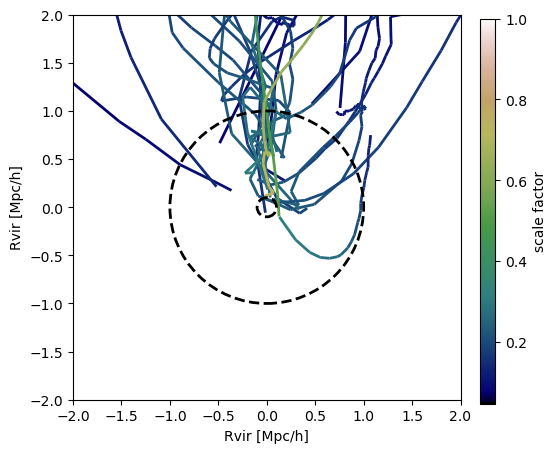

In [9]:
hid = 5
fig, ax = plt.subplots(figsize=(5, 5))

for i in range(1, len(mw_halos[hid])): 
    lines = color_line(ax, 
               mw_halos[hid][i]['Rratio']*np.sin(mw_halos[hid][i]['theta'])*np.cos(mw_halos[hid][i]['phi']),  
            mw_halos[hid][i]['Rratio']*np.sin(mw_halos[hid][i]['theta'])*np.sin(mw_halos[hid][i]['phi']),
            mw_halos[hid][i]['scale'], 
               None)

print(i)
plt.xlim(-2, 2)
plt.ylim(-2, 2)

    
circle1 = plt.Circle((0, 0), 1, color='black', fill=None, ls='--', lw=2, 
                     zorder=100)
ax.add_patch(circle1)
circle1 = plt.Circle((0, 0), 0.1, color='black', fill=None, ls='--', lw=2, 
                     zorder=100)
ax.add_patch(circle1)


plt.xlabel('Rvir [Mpc/h]') 
plt.ylabel('Rvir [Mpc/h]')

axins = inset_axes(ax, # here using axis of the lowest plot
               width="4%",  # width = 5% of parent_bbox width
               height="100%",  # height : 340% good for a (4x4) Grid
               loc='lower left',
               bbox_to_anchor=(1.05, -0.01, 1, 1),
               bbox_transform=ax.transAxes,
               borderpad=0,
               )

axcb = fig.colorbar(lines, cax=axins, label=r'scale factor')

In [17]:
from astropy.table import QTable


In [18]:
QTable.from_pandas(mw_halos[3][3])

Mvir,Rvir,vmax,scale,cnfw,Rratio,theta,phi
float64,float64,float64,float64,float64,float64,float64,float64
8.606270900739467,1.3797140980717881,28.299999237060547,0.10582999885082245,7.324763298034668,0.43817779089385106,1.896999867754527,1.1038776636123657
8.24579525136173,1.2595892090685228,21.40999984741211,0.09997999668121338,4.869513511657715,0.9312739194011791,1.7580592950158795,0.8788093328475952
8.239562129431508,1.257609846519036,21.93000030517578,0.09625999629497528,3.621565580368042,1.2484824883079724,1.8048386891656598,0.8338600993156433
8.233612796918306,1.2555858163997342,22.420000076293945,0.09093999862670898,2.8771514892578125,1.7657229508008068,1.6654838641458234,1.0796699523925781
8.30396917801185,1.2790706745739597,23.389999389648438,0.08349999785423279,1.0463037490844727,2.557929053971515,1.61829665501649,1.199914574623108
8.176902585692128,1.2366720155513626,22.540000915527344,0.07704000174999237,3.551839590072632,3.221608676988481,1.631178768473216,1.2472739219665527
7.7354744292162,1.089643354841607,18.540000915527344,0.06254000216722488,5.034461498260498,4.781361352767735,1.785659821825572,0.9587944746017456
7.287419533780868,0.9403011421954316,14.609999656677246,0.04751000180840492,3.8487610816955566,5.396952126511195,2.1269085725122174,0.5515190958976746


In [16]:
mw_halos[3][3]

,Mvir,Rvir,vmax,scale,cnfw,Rratio,theta,phi
0,8.606271,1.379714,28.299999,0.10583,7.324763,0.438178,1.897000,1.103878
1,8.245795,1.259589,21.410000,0.09998,4.869514,0.931274,1.758059,0.878809
2,8.239562,1.257610,21.930000,0.09626,3.621566,1.248482,1.804839,0.833860
3,8.233613,1.255586,22.420000,0.09094,2.877151,1.765723,1.665484,1.079670
4,8.303969,1.279071,23.389999,0.08350,1.046304,2.557929,1.618297,1.199915
5,8.176903,1.236672,22.540001,0.07704,3.551840,3.221609,1.631179,1.247274
6,7.735474,1.089643,18.540001,0.06254,5.034461,4.781361,1.785660,0.958794
7,7.287420,0.940301,14.610000,0.04751,3.848761,5.396952,2.126909,0.551519


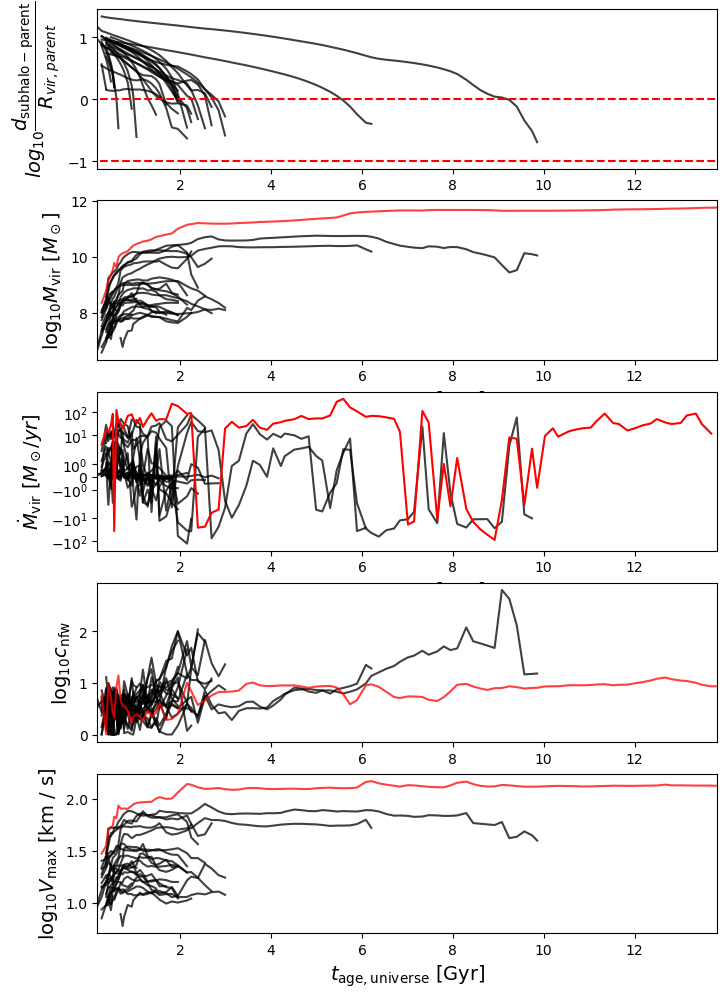

In [10]:
hid = 5

fig, axes = plt.subplots(5, 1, figsize=(8, 12)) 

for i in range(1, len(mw_halos[hid])): 
    axes[0].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), 
                 np.log10(mw_halos[hid][i]['Rratio']), c='black', alpha=0.75)
axes[0].hlines(y=[-1, 0], xmin=0, xmax=cosmo_15.age(0).value, ls='--', color='red')
axes[0].set_ylabel(r'${log}_{10} \dfrac{d_{\rm subhalo-parent}}{R_{vir, parent}}$', fontsize=14)


for i in range(1, len(mw_halos[hid])): 
    axes[1].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), 
                 mw_halos[hid][i]['Mvir'], c='black', alpha=0.75)
axes[1].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'] - 1), 
             mw_halos[hid][0]['Mvir'], c='red', alpha=0.75)
axes[1].set_ylabel(r'${\rm log}_{10} M_{\rm vir}$ [$M_\odot$]', fontsize=14)
    
    
for i in range(1, len(mw_halos[hid])): 
    mvir = 10**mw_halos[hid][i]['Mvir'][::-1]
    age = cosmo_15.age(1/mw_halos[hid][i]['scale'][::-1] - 1).value * 1e9
    axes[2].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'][1:][::-1] - 1),
                 np.diff(mvir) / np.diff(age), c='black', alpha=0.75)
mvir = 10**mw_halos[hid][0]['Mvir'][::-1]
age = cosmo_15.age(1/mw_halos[hid][0]['scale'][::-1] - 1).value * 1e9
axes[2].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'][1:][::-1] - 1), 
             np.diff(mvir) / np.diff(age), c='red')
axes[2].set_ylabel(r'$\dot{M}_{\rm vir}$ [$M_\odot / yr$]', fontsize=14)
axes[2].set_yscale('symlog')

for i in range(1, len(mw_halos[hid])): 
    axes[3].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), 
                 np.log10(mw_halos[hid][i]['cnfw']), c='black', alpha=0.75)
axes[3].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'] - 1), 
             np.log10(mw_halos[hid][0]['cnfw']), c='red', alpha=0.75)
axes[3].set_ylabel(r'${\rm log}_{10} c_{\rm nfw}$', fontsize=14)


for i in range(1, len(mw_halos[hid])): 
    axes[4].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), 
                 np.log10(mw_halos[hid][i]['vmax']), c='black', alpha=0.75)
axes[4].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'] - 1), 
             np.log10(mw_halos[hid][0]['vmax']), c='red', alpha=0.75)
axes[4].set_ylabel(r'${\rm log}_{10} V_{\rm max}$ [km / s]', fontsize=14)

_ = [ax.set_xlim(cosmo_15.age(20.05).value, cosmo_15.age(0).value) for ax in axes.flatten()]
_ = [ax.set_xlabel(r'$t_{\rm age, universe}$ [Gyr]', fontsize=14) for ax in axes.flatten()]

# _ = [ax.set_xscale('log') for ax in axes.flatten()]

In [237]:
# for i in range(1, len(mw_halos[hid])): 
#     plt.plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), mw_halos[hid][i]['Rratio'], c='black', alpha=0.75)
    
# plt.hlines(y=[0.1, 1], xmin=0, xmax=cosmo_15.age(0).value, ls='--', color='red')
# # plt.ylim(0, 3)

# plt.xlim(cosmo_15.age(20.05).value, cosmo_15.age(0).value)

# plt.xlabel(r'$t_{\rm age, universe}$ [Gyr]', fontsize=14)
# plt.ylabel(r'$\dfrac{d_{\rm subhalo-parent}}{R_{vir, parent}}$', fontsize=14)

# plt.yscale('log')

In [239]:
# hid = 22

# fig, axes = plt.subplots(2, 2, figsize=(8, 8)) 

# for i in range(1, len(mw_halos[hid])): 
#     axes[0][0].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), mw_halos[hid][i]['Mvir'], c='black', alpha=0.75)
# axes[0][0].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'] - 1), mw_halos[hid][0]['Mvir'], c='red', alpha=0.75)
# axes[0][0].set_ylabel(r'${\rm log}_{10} M_{\rm vir} [M_\odot]$', fontsize=14)
    

# for i in range(1, len(mw_halos[hid])): 
#     axes[0][1].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), np.log10(mw_halos[hid][i]['cnfw']), c='black', alpha=0.75)
# axes[0][1].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'] - 1), np.log10(mw_halos[hid][0]['cnfw']), c='red', alpha=0.75)
# axes[0][1].set_ylabel(r'${\rm log}_{10} c_{\rm nfw} $', fontsize=14)


# for i in range(1, len(mw_halos[hid])): 
#     axes[1][1].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'] - 1), np.log10(mw_halos[hid][i]['vmax']), c='black', alpha=0.75)
# axes[1][1].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'] - 1), np.log10(mw_halos[hid][0]['vmax']), c='red', alpha=0.75)
# axes[1][1].set_ylabel(r'${\rm log}_{10} V_{\rm max} []$', fontsize=14)


# for i in range(1, len(mw_halos[hid])): 
#     mvir = 10**mw_halos[hid][i]['Mvir'][::-1]
#     age = cosmo_15.age(1/mw_halos[hid][i]['scale'][::-1] - 1).value * 1e9
#     axes[1][0].plot(cosmo_15.age(1/mw_halos[hid][i]['scale'][1:][::-1] - 1), np.diff(mvir) / np.diff(age), c='black', alpha=0.75)
# mvir = 10**mw_halos[hid][0]['Mvir'][::-1]
# age = cosmo_15.age(1/mw_halos[hid][0]['scale'][::-1] - 1).value * 1e9
# axes[1][0].plot(cosmo_15.age(1/mw_halos[hid][0]['scale'][1:][::-1] - 1), np.diff(mvir) / np.diff(age), c='red')
# axes[1][0].set_ylabel(r'$\dot{M}_{\rm vir}$ [$M_\odot / yr$]', fontsize=14)
# axes[1][0].set_yscale('symlog')
# _ = [ax.set_xlim(cosmo_15.age(20.05).value, cosmo_15.age(0).value) for ax in axes.flatten()]
# _ = [ax.set_xlabel(r'$t_{\rm age, universe}$ [Gyr]', fontsize=14) for ax in axes.flatten()]
# # _ = [ax.set_xscale('log') for ax in axes.flatten()]

In [209]:
np.symlog

AttributeError: module 'numpy' has no attribute 'symlog'

(-2.0, 2.0)

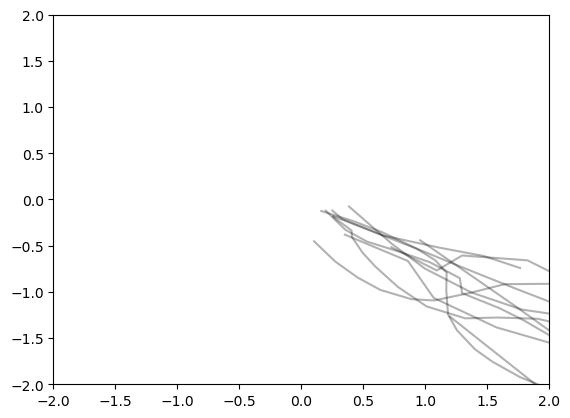

In [205]:
hid = 16
for i in range(1, len(mw_halos[hid])): 
    plt.plot(mw_halos[hid][i]['Rratio']*np.sin(mw_halos[hid][i]['theta'])*np.cos(mw_halos[hid][i]['phi']) , 
             mw_halos[hid][i]['Rratio']*np.cos(mw_halos[hid][i]['theta']), c='black', 
            alpha=0.3)
    
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9)) 

q = np.log10(np.array([node['Mvir'].value for node in tree_nodes[branch_idx[0][0]:branch_idx[0][1]]]))
scale = 1/np.array([node['scale'] for node in tree_nodes[branch_idx[0][0]:branch_idx[0][1]]]) - 1

axes[0][0].plot(scale, mvir, c='red')

for idx in branch_idx[1:]:
    q = np.log10(np.array([node['Mvir'].value for node in tree_nodes[idx[0]:idx[1]]]))
    scale = 1/np.array([node['scale'] for node in tree_nodes[idx[0]:idx[1]]]) - 1

    axes[0][0].plot(scale, mvir, c='black', alpha=0.75)
    


In [ ]:
scale

In [ ]:
cnfw = float(node['Rvir'] / node['rs'])

In [ ]:
tree_nodes[960]['desc_id']

In [ ]:
def r_d(sub, par): 
    print(((sub[0] - par[0])**2 + (sub[1] - par[1])**2 + (sub[2] - par[2])**2)**(0.5) )

In [ ]:
main_ids = np.array([node['id'] for node in tree_nodes[branch_idx[0, 0]:branch_idx[0, 1]]])

main_ids
# tree_nodes[branch_idx[1, 0]]["desc_id"]

In [ ]:
for j in range(branch_idx[1][0], branch_idx[1][1]): 
    print(j)

In [ ]:
for j in 
r_d(np.array([float(tree_nodes[np.where(tree_nodes[branch_idx[1][0]]['desc_id'] == main_ids)[0][0]][c]) for c in ['x', 'y', 'z']]), 
    np.array([float(tree_nodes[branch_idx[1][0]][c]) for c in ['x', 'y', 'z']]))

In [ ]:
i = 0 
for node in tree_nodes[branch_idx[i, 0]:branch_idx[i, 1]]:
    print([float(node[c]) for c in ['Mvir', 'Rvir', 'vmax', 'scale']])

In [ ]:
branch_idx[:, -1] - branch_idx[:, 0]

In [ ]:
plt.plot(branch_idx[:, 1] - branch_idx[:, 0], )


In [ ]:
len(branch_idx)

In [ ]:
branch_idx[0:20]